In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 494kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.11MB/s]


In [4]:
class AdaptiveAutoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Flatten(),

            nn.Linear(784,512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(512,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256,64)

        )

        self.decoder = nn.Sequential(

            nn.Linear(64,256),
            nn.ReLU(),

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,784),

            nn.Sigmoid()

        )

    def forward(self,x):

        z = self.encoder(x)

        x = self.decoder(z)

        x = x.view(-1,1,28,28)

        return x,z

In [5]:
model = AdaptiveAutoencoder().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [6]:
epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images,_ in train_loader:

        images = images.to(device)

        outputs,latent = model(images)

        loss = criterion(outputs,images)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1} Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch 1 Loss: 0.0315
Epoch 2 Loss: 0.0159
Epoch 3 Loss: 0.0128
Epoch 4 Loss: 0.0112
Epoch 5 Loss: 0.0103
Epoch 6 Loss: 0.0096
Epoch 7 Loss: 0.0092
Epoch 8 Loss: 0.0088
Epoch 9 Loss: 0.0085
Epoch 10 Loss: 0.0082


In [7]:
model.eval()

image,_ = next(iter(test_loader))

image = image.to(device)

with torch.no_grad():

    reconstruction,latent = model(image)

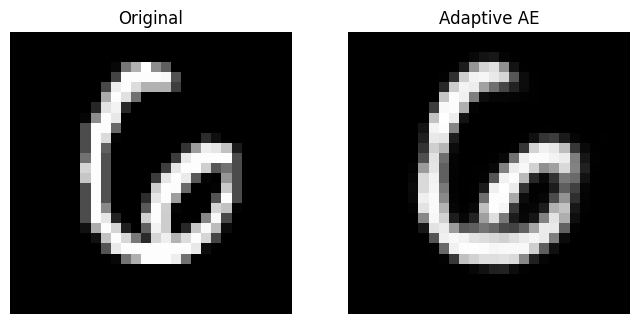

In [8]:
original = image.cpu().squeeze().numpy()

reconstructed = reconstruction.cpu().squeeze().numpy()

plt.figure(figsize=(8,4))

plt.subplot(121)

plt.imshow(original,cmap="gray")

plt.title("Original")

plt.axis("off")

plt.subplot(122)

plt.imshow(reconstructed,cmap="gray")

plt.title("Adaptive AE")

plt.axis("off")

plt.show()